In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import re
import seaborn as sns
from math import radians, sin, cos, asin, sqrt
import imageio
import os
from IPython.display import Image, display
import time
from scipy.stats import gaussian_kde
from statistics import mean
import statistics
import random

In [2]:
plotdir = 'plots/'

In [3]:
Ms = 10 #number of importance samples
CHR = 2
tCutoff = 'None'
samples = range(1746*2)
ancestor_loci = [int(i * 51845 / 999) for i in range(1000)]

In [5]:
sample_locs = np.loadtxt("data/SGDP_aDNA_new_filtered.locations")
sample_locs= sample_locs[:, [1, 0]] #Flip it so it transforms from lat-lon to lon-lat (same format as anc_locs)
print(sample_locs.shape)

(3492, 2)


In [6]:
df_poplabels = pd.read_csv("data/SGDP_aDNA_new_filtered_chr2.poplabels", header=None, delim_whitespace=True, skiprows=1,
                            names=["ID", "pop", "group", "sex"])
df_poplabels.drop(columns=["sex"], inplace=True)
df_poplabels.head
                       

/tmp/ipykernel_2002947/2919367699.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_poplabels = pd.read_csv("data/SGDP_aDNA_new_filtered_chr2.poplabels", header=None, delim_whitespace=True, skiprows=1,


<bound method NDFrame.head of                      ID                       pop        group
0     B_Australian-3.DG                Australian      Oceania
1     B_Australian-4.DG                Australian      Oceania
2          B_Crete-1.DG                     Crete  WestEurasia
3          B_Crete-2.DG                     Crete  WestEurasia
4            B_Dai-4.DG                       Dai     EastAsia
...                 ...                       ...          ...
1741             wes056  north_Sweden_Late_Viking       Sweden
1742            Yamnaya                   Yamnaya   Kazakhstan
1743         Yana_young          Yana_Medieval.SG       Russia
1744              Yana1                Yana_UP.SG       Russia
1745              Yana2                Yana_UP.SG       Russia

[1746 rows x 3 columns]>

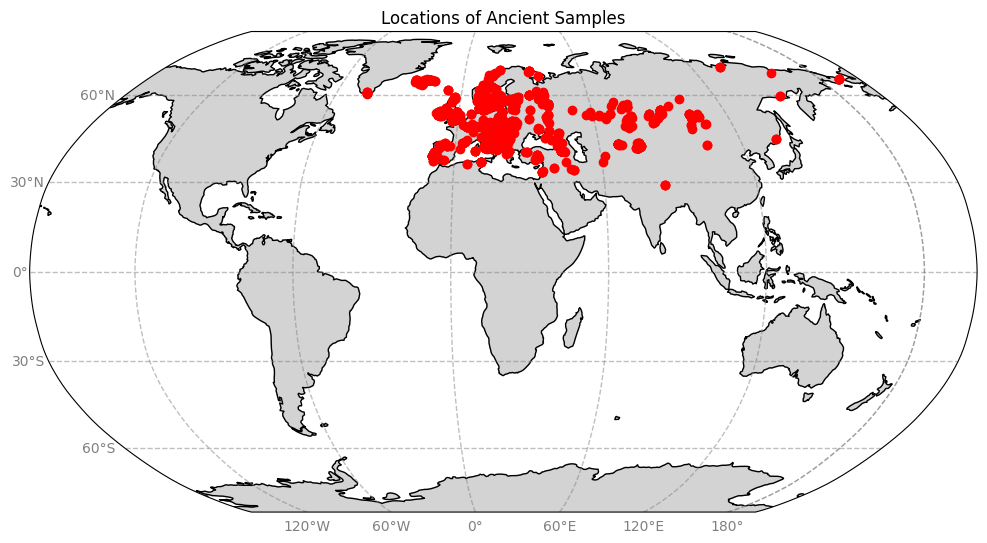

In [8]:
#Code to test if locations matches up with poplabels. It does.
fig = plt.figure(figsize=(10, 6), dpi=100)
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree()  # lat/lon
ax = plt.axes(projection=projection)
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

for sample in range (278, 1746):
    sample = sample * 2 #Diploid
    location = sample_locs[sample]
    lon, lat = location[0], location[1]
    ax.plot([lon], [lat], marker='o', color='red', markersize=6, transform=data_crs)
    

# # Plot the point
# ax.plot([lon], [lat], marker='o', color='red', markersize=6, transform=data_crs)
# ax.text(lon, lat, str(sample), transform=data_crs, fontsize=8,
#         ha='left', va='bottom', color='black', weight='bold')

# Show immediately
plt.title(f"Locations of Ancient Samples")
plt.tight_layout()
plt.show()

Number of samples: 1169


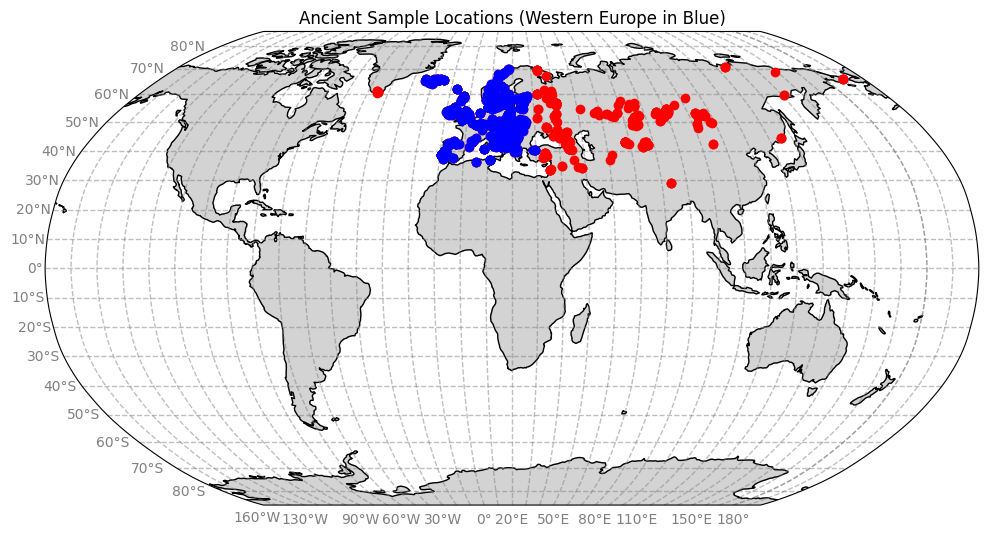

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Define projection and CRS
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree()

# Create figure and map axes
fig = plt.figure(figsize=(10, 6), dpi=100)
ax = plt.axes(projection=projection)
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')

# Add gridlines (finer resolution)
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}
gl.xlocator = mticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = mticker.FixedLocator(range(-90, 91, 10))

# Define Western Europe bounding box (approx.)
min_lon, max_lon = -30, 30
min_lat, max_lat = 35, 75

# Collect Western European samples
western_europe_samples = []

# Loop through all samples and plot
for sample in range(278, 1746):
    sample_idx = sample * 2  # Diploid index
    lon, lat = sample_locs[sample_idx]

    # Plot all samples in red
    ax.plot([lon], [lat], marker='o', color='red', markersize=6, transform=data_crs)

    # Check if the sample is in Western Europe
    if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
        western_europe_samples.append((sample_idx, lon, lat))

# Plot Western European samples in blue (on top)
for sample_idx, lon, lat in western_europe_samples:
    ax.plot([lon], [lat], marker='o', color='blue', markersize=6, transform=data_crs)
    
print(f'Number of samples: {len(western_europe_samples)}')
# Final touches
plt.title("Ancient Sample Locations (Western Europe in Blue)")
plt.tight_layout()
plt.show()


Number of samples: 39


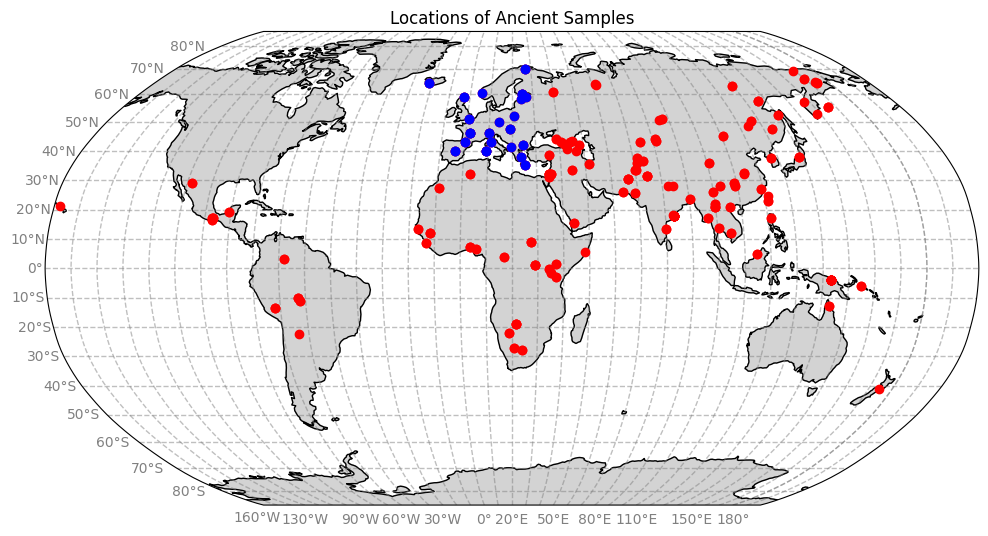

In [24]:
#Code to test if locations matches up with poplabels. It does.
fig = plt.figure(figsize=(10, 6), dpi=100)
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree()  # lat/lon
ax = plt.axes(projection=projection)
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}
gl.xlocator = mticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = mticker.FixedLocator(range(-90, 91, 10))

min_lon, max_lon = -30, 30
min_lat, max_lat = 35, 75

western_europe_samples = []
for sample in range (0, 278):
    sample = sample * 2 #Diploid
    location = sample_locs[sample]
    lon, lat = location[0], location[1]
    ax.plot([lon], [lat], marker='o', color='red', markersize=6, transform=data_crs)
    
    if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
            western_europe_samples.append((sample_idx, lon, lat))

# Plot Western European samples in blue (on top)
for sample_idx, lon, lat in western_europe_samples:
    ax.plot([lon], [lat], marker='o', color='blue', markersize=6, transform=data_crs)

# # Plot the point
# ax.plot([lon], [lat], marker='o', color='red', markersize=6, transform=data_crs)
# ax.text(lon, lat, str(sample), transform=data_crs, fontsize=8,
#         ha='left', va='bottom', color='black', weight='bold')

print(f'Number of samples: {len(western_europe_samples)}')
# Show immediately
plt.title(f"Locations of Ancient Samples")
plt.tight_layout()
plt.show()